In [3]:
# Config & wandb init

import wandb

config = {
    'learning_rate': 2e-5,
    'model': 'klue/bert-base',  
    'dataset': 'nsmc',
    'epochs': 3,
    'batch_size': 2,
    'weight_decay': 0.01,
}

wandb.init(
    project="Korean_Sentiment_Analysis_gpu",
    name="KLUE-BERT-Sentiment",
    tags=["Korean", "Sentiment Analysis", "KLUE-BERT"],
    group="NLP",
    notes="KLUE-BERT model for sentiment analysis on nsmc dataset",
    config=config
)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: changeun8459 (changeun8459-korea-university-of-technology-and-education) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
# Dataset load
from datasets import load_dataset

dataset = load_dataset(wandb.config.dataset, trust_remote_code=True)

In [5]:
# Load tokenizer and model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(wandb.config.model)
model = AutoModelForSequenceClassification.from_pretrained(wandb.config.model, num_labels=2)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
This can be used to load a bitsandbytes version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=
If you use the manual override make sure the right libcudart.so is in your LD_LIBRARY_PATH
For example by adding the following to your .bashrc: export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:<path_to_cuda_dir/lib64

Could not find the bitsandbytes CUDA binary at PosixPath(

In [6]:
# Tokenize dataset

def preprocess_function(examples):
    return tokenizer(examples["document"], padding="max_length", truncation=True)

tokenized_datasets = dataset.map(preprocess_function, batched=True).shuffle()

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [7]:
# Define metrics

import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
    }

In [8]:
# Define training arguments

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=wandb.config.batch_size,
    per_device_eval_batch_size=wandb.config.batch_size,
    gradient_accumulation_steps=8,  # 
    num_train_epochs=wandb.config.epochs,
    weight_decay=wandb.config.weight_decay,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    run_name="KLUE-BERT-Sentiment",
)

In [9]:
# Define trainer

import torch
from transformers import Trainer

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Trainer 실행
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:446: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None)
  warnings.warn(
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [10]:
# Initial evaluate results

initial_results = trainer.evaluate()
print(f"Initial Evaluation: {initial_results}")

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Initial Evaluation: {'eval_loss': 0.7041682600975037, 'eval_accuracy': 0.49098, 'eval_runtime': 654.8417, 'eval_samples_per_second': 76.354, 'eval_steps_per_second': 38.177}


In [11]:
import torch
torch.cuda.empty_cache()  # GPU 캐시 정리

In [12]:
# Train the model

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.345100,0.274748,0.892180
2,0.185800,0.282229,0.900700
3,0.096800,0.397376,0.901280


TrainOutput(global_step=28125, training_loss=0.21232508114086257, metrics={'train_runtime': 20405.6513, 'train_samples_per_second': 22.053, 'train_steps_per_second': 1.378, 'total_flos': 1.18399974912e+17, 'train_loss': 0.21232508114086257, 'epoch': 3.0})

In [13]:
# Evaluate the model

final_results = trainer.evaluate()
print(f"Final Evaluation: {final_results}")

Final Evaluation: {'eval_loss': 0.2747478485107422, 'eval_accuracy': 0.89218, 'eval_runtime': 655.2264, 'eval_samples_per_second': 76.31, 'eval_steps_per_second': 38.155, 'epoch': 3.0}


In [14]:
# Wandb finish

wandb.finish()

eval/accuracy,▁████
eval/loss,█▁▁▃▁
eval/runtime,▁█▁▁▁
eval/samples_per_second,█▁███
eval/steps_per_second,█▁███
train/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇██
train/global_step,▁▁▁▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train/learning_rate,█████▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▅▄▄▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁
train/loss,▆██▅▅▅▅▆▅▅▄▄▅▄▄▂▃▂▃▃▃▂▃▃▃▃▂▃▂▃▂▂▂▂▃▁▂▃▂▁
train/total_flos,▁
train/train_loss,▁


# Review

## requirement
- 한국어 감정분석 데이터를 활용해 한국어 모델 학습

1. 데이터셋 선정
2. 학습 모델 선정
3. 초기 모델 평가
4. 모델 학습
5. 학습 후 모델 평가

## Introduction
### 1. 연구 목적 및 배경

감정 분석(Sentiment Analysis)은 자연어 처리(NLP) 분야에서 중요한 연구 주제 중 하나로,  
다양한 산업 분야에서 텍스트 데이터를 기반으로 감성 및 의견을 분석하는 데 활용된다. 대표적인 응용 사례로는 소셜 미디어 분석, 리뷰 감성 분석, 고객 피드백 분석 등이 있다.

본 연구에서는 KLUE-BERT를 활용하여 한국어 감정 분석을 수행하고,   
네이버 영화 리뷰(NSMC) 데이터셋을 이용하여 학습 및 평가를 진행한다. 이를 통해,  

- KLUE-BERT가 감정 분석 태스크에서 적절한 모델인지 검증하고,
- 학습 전후의 성능을 비교하여 모델의 학습 효과를 분석하며,
- 향후 연구에서 개선할 수 있는 방향성을 제시하는 것을 목표로 한다.


## Methodology
### 1. 데이터셋 선정 및 개요

#### 1.1. NSMC(Naver Sentiment Movie Corpus) 데이터셋
본 연구에서는 한국어 감정 분석의 대표적인 벤치마크 데이터셋인 **NSMC(Naver Sentiment Movie Corpus)**를 활용한다.  
해당 데이터셋은 네이버 영화 리뷰에서 긍정(1)과 부정(0)의 감정을 라벨링한 문장 데이터로 구성되며, 다음과 같은 특징을 가진다. 

- 총 데이터 개수: 200,000개 (학습 150,000개, 테스트 50,000개)
- 이진 감정 분류 문제: 긍정(1) 또는 부정(0)으로 분류
- 문장 길이: 최소 1자에서 최대 140자로 구성

#### 1.2. NSMC 데이터셋 선정 이유
NSMC 데이터셋을 본 연구에 적용한 이유는 다음과 같다.

- 한국어 감정 분석 연구에서 **가장 널리 사용되는 벤치마크 데이터셋**
- 영화 리뷰라는 현실적인 텍스트 데이터 기반, 실제 감정 분석 모델이 적용될 서비스와 유사
- 긍정/부정 라벨링이 명확하게 제공, 이진 분류 문제로 학습하기 용이
- 공개된 데이터셋으로 접근성이 높고, 학술적 연구에서 검증된 데이터

### 2. KLUE-BERT 모델 선정 이유

본 연구에서는 한국어 감정 분석을 위해 KLUE-BERT(klue/bert-base) 모델을 사용하였다. KLUE-BERT를 선정한 이유는 다음과 같다.

- 한국어에 특화된 BERT 모델로, **한국어 텍스트 처리 성능이 우수함**
- 다양한 한국어 데이터셋(뉴스, 법률, 위키백과 등)으로 사전 학습됨, 일반적인 **한국어 감정 분석 태스크에 적합**
- 기존 KoBERT(SK텔레콤 제공) 대비 성능이 향상되었으며, 한국어 문맥 이해력이 뛰어남

## Results & Analysis

### 1. 학습 전 모델 평가 결과
모델을 학습하기 전에 trainer.evaluate()를 실행한 결과는 다음과 같다.

`Initial Evaluation: {'eval_loss': 0.7041, 'eval_accuracy': 0.4909}`

- 초기 평가 정확도(Accuracy): 49.09%
- 손실 함수 값(Loss): 0.7041  

**➡ 초기 모델은 랜덤 분류 수준(약 50%)에 머물러 있으며, 학습이 필요함을 확인할 수 있음.**

### 2. 학습 후 모델 성능
#### 2.1. 손실 및 정확도 분석

아래 wandb 그래프에서 `eval/loss` 값은 학습 초기에 급격히 감소한 후 안정화되었으며,   
`eval/accuracy` 값은 점진적으로 증가하여 최종적으로 89%에 도달하였다.  
이를 통해 KLUE-BERT 모델이 NSMC 감정 분석 태스크에서 적절히 학습되었음을 확인할 수 있다.  

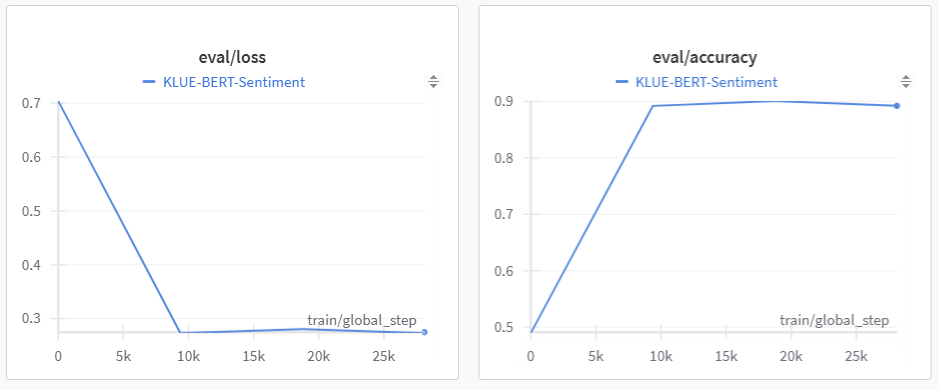

모델 학습을 진행한 후, 각 Epoch에서의 성능 변화는 다음과 같다.

| Epoch | Training Loss | Validation Loss | Accuracy |
|-------|--------------|----------------|----------|
| 1     | 0.3451       | 0.2747         | 89.21%   |
| 2     | 0.1858       | 0.2822         | 90.07%   |
| 3     | 0.0968       | 0.3973         | 90.12%   |

- Epoch 1부터 학습이 진행되면서 Validation Accuracy가 급격히 향상됨.
- Training Loss는 계속 감소하지만, Epoch 3에서 Validation Loss가 다소 증가 → Overfitting 가능성이 있음.
- 최종 모델의 평가 결과:  

`Final Evaluation: {'eval_loss': 0.2747, 'eval_accuracy': 0.8921}`

**➡ KLUE-BERT 모델은 학습 후 정확도 89.21%를 달성하며, 감정 분석에서 좋은 성능을 보임.**

## Conclusion

### 1. KLUE-BERT 성능 요약

- KLUE-BERT 모델을 NSMC 데이터셋에 Fine-tuning한 결과, 초기 49.09% → 최종 89.21% 정확도 향상
- 기존 BERT 계열 모델 대비 한국어 감정 분석에서 뛰어난 성능을 보임
- 문맥적 정보를 활용하여 감정 분석을 효과적으로 수행함을 확인

### 2. 실험의 한계점

본 실험에서는 학교에서 제공하는 GPU 환경에서 **OOM(Out of Memory) 오류가 발생**하여, GPU 메모리 사용을 최적화하기 위해  
batch_size=2로 설정하고, **gradient_accumulation_steps=8** 을 적용하여 실제 batch_size=16과 동일한 효과를 얻도록 하였다.   
하지만 이 방식에는 다음과 같은 한계점이 존재한다.

1) 학습 속도의 저하  
- 작은 batch_size=2로 인해 한 번의 weight update까지 8개의 mini-batch를 처리해야 하므로, 학습 속도가 느려짐.

2) Gradient Update Frequency 감소로 인한 학습 최적화 문제  
- gradient_accumulation_steps=8을 사용하면 한 번의 가중치 업데이트를 위해 여러 step 동안 gradient를 누적해야 함.
- 이로 인해, batch normalization이나 optimizer의 momentum 효과가 약화될 가능성이 있음.

### 3. 향후 개선 방향

위에서 언급한 문제를 해결하고 KLUE-BERT의 학습 효율성을 높이기 위해 다음과 같은 개선 방향을 고려할 수 있다.

1) Batch Size 증가
- 찾아본 결과, GPU 메모리 제한을 해결하기 위해 Mixed Precision Training (FP16) 을 적용하면,  
모델 메모리 사용량을 절반으로 줄이면서 더 큰 batch size 사용 가능.
2) 더 효율적인 한국어 모델 비교 실험
- KLUE-BERT 대신 더 가벼운 모델(KoBERT, DistilBERT, KorELECTRA 등) 을 사용하면, 적은 GPU 메모리로도 학습 가능.
3) Learning Rate 튜닝 및 Warmup 적용
- 작은 batch size를 사용할 경우, learning rate를 너무 크게 설정하면 학습이 불안정해질 가능성이 있음.
- learning_rate를 감소시키고, warmup_steps을 추가하여 학습 초기에 안정적인 학습을 유도함.